 https://huggingface.co/datasets/ErfanMoosaviMonazzah/fake-news-detection-dataset-English

Installing libraries and importing modules while preparing environment, loading datasets, and enabling text processing pipeline.

In [1]:
!pip install wordcloud -q
!pip install nltk spacy -q
!python -m spacy download en_core_web_sm

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import spacy
import torch
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer)
from datasets import Dataset
# import numpy as np
# import pandas as pd
# import re
# import matplotlib.pyplot as plt
# import seaborn as sns
# from wordcloud import WordCloud
# sns.set(style="whitegrid")
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import LinearSVC
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# import nltk
# from nltk.corpus import stopwords
# import spacy
# import torch
# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification,
#     TrainingArguments,
#     Trainer
# )
# from datasets import Dataset
# from sklearn.model_selection import cross_val_score
# from sklearn.metrics import f1_score, precision_score, recall_score
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix
# from datasets import Dataset
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# import numpy as np
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report


# from google.colab import drive
# drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Setting display options, configuring pandas output, and confirming successful loading of required libraries.

In [2]:
# Displaing settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print(" Libraries loaded successfully")

 Libraries loaded successfully


Defining dataset file paths, assigning train, test, validation locations, and confirming correct path setup.

In [3]:
train_path = "/content/train.tsv"
test_path = "/content/test.tsv"
val_path = "/content/validation.tsv"
print(" Paths set correctly")

 Paths set correctly


Loading TSV datasets, reading train test validation files, and displaying dataset shapes successfully.

In [4]:
train_df = pd.read_csv(train_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')
val_df = pd.read_csv(val_path, sep='\t')
print(" TSV Data loaded successfully")
print("\nTrain Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Validation Shape:", val_df.shape)

 TSV Data loaded successfully

Train Shape: (30000, 6)
Test Shape: (8267, 6)
Validation Shape: (6000, 6)


Displaying training dataset, showing initial records, and inspecting data structure for understanding.

In [5]:
print("TRAIN DATA")
display(train_df.head())

TRAIN DATA


,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,19963,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,10783,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0


Presenting test dataset, previewing sample entries, and examining structure for initial insights.

In [6]:
print("\nTEST DATA")
display(test_df.head())


TEST DATA


,Unnamed: 0,title,text,subject,date,label
0,8104,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,7467,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,9473,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,276,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,19274,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0


Revealing validation dataset, viewing first rows, and exploring format for further analysis.

In [7]:
print("\nVALIDATION DATA")
display(val_df.head())


VALIDATION DATA


,Unnamed: 0,title,text,subject,date,label
0,14074,TRUMP HATER GEORGE RAMOS Promotes Movie Showin...,Mexico has been the beneficiary of our open bo...,politics,"Apr 20, 2016",0
1,17592,Germany seeks to maintain unity if U.S. decert...,The German government on Friday vowed to work ...,worldnews,"October 13, 2017",1
2,5694,No sign U.S. wants to cancel nuclear deal with...,German Foreign Minister Sigmar Gabriel said it...,politicsNews,"February 2, 2017",1
3,20036,Brazil prosecutors seek to extend Batista dete...,The Office of Brazil s Prosecutor-General Rodr...,worldnews,"September 14, 2017",1
4,234,Trump Just Asked The Most Unqualified Person E...,"Trump, who keeps promising to either scrap our...",News,"October 10, 2017",0


Listing column names, retrieving feature labels, and verifying schema consistency across all datasets.

In [8]:
print(" Train Columns:", train_df.columns.tolist())
print(" Test Columns:", test_df.columns.tolist())
print(" Validation Columns:", val_df.columns.tolist())

 Train Columns: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']
 Test Columns: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']
 Validation Columns: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']


Inspecting dataset details, summarizing structure, and checking data types with memory usage information.

In [9]:
print(" TRAIN INFO")
train_df.info()

 TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30000 non-null  int64 
 1   title       30000 non-null  object
 2   text        30000 non-null  object
 3   subject     30000 non-null  object
 4   date        30000 non-null  object
 5   label       30000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.4+ MB


Reviewing test dataset details, outlining structure, and verifying data types with memory summary.

In [10]:
print("\n TEST INFO")
test_df.info()


 TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  8267 non-null   int64 
 1   title       8267 non-null   object
 2   text        8267 non-null   object
 3   subject     8267 non-null   object
 4   date        8267 non-null   object
 5   label       8267 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 387.6+ KB


Assessing validation dataset information, outlining structure, and confirming data types with memory details.

In [11]:
print("\n VALIDATION INFO")
val_df.info()


 VALIDATION INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6000 non-null   int64 
 1   title       6000 non-null   object
 2   text        6000 non-null   object
 3   subject     6000 non-null   object
 4   date        6000 non-null   object
 5   label       6000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 281.4+ KB


Calculating null counts, aggregating results, and presenting combined summary across train, test, validation datasets.

In [12]:
# Combining missing values into one DataFrame
print(" Missing Values for the Train, Test and Validation: ")
missing_df = pd.DataFrame({
    "Train": train_df.isnull().sum(),
    "Test": test_df.isnull().sum(),
    "Validation": val_df.isnull().sum()
})
display(missing_df)

 Missing Values for the Train, Test and Validation: 


,Train,Test,Validation
Unnamed: 0,0,0,0
title,0,0,0
text,0,0,0
subject,0,0,0
date,0,0,0
label,0,0,0


Identifying distinct entries, iterating columns, and inspecting sample unique values for each feature.

In [13]:
# Checking unique values in each column
for col in train_df.columns:
    print(f"\n Column: {col}")
    print("Unique Values (sample):")
    print(train_df[col].astype(str).unique()[:10])


 Column: Unnamed: 0
Unique Values (sample):
['2619' '16043' '876' '19963' '10783' '18522' '270' '7628' '9599' '11234']

 Column: title
Unique Values (sample):
["Ex-CIA head says Trump remarks on Russia interference 'disgraceful'"
 'YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STORE OWNER Swindles Tax Payers Out Of $1,116,924.27 In Latest Food Stamp Scam'
 "Federal Reserve governor Powell's policy views, in his own words"
 'SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks” Campaign…Desperate Move!'
 'NANCY PELOSI ARROGANTLY DISMISSES Questions on Crooked Democrat IT Employees Under Investigation [Video]'
 "EU's Tusk appealed to Rajoy to avoid escalation in Catalonia"
 'Country Guitarist Who Survived Vegas Shooting Changes Mind On Gun Control: ‘How Wrong I Was’'
 "Clinton says 'there is no case here' in FBI email investigation"
 'ABC NEWS REPORTS: Las Vegas Massacre Suspect’s Hard Drive Is MISSING From His Laptop'
 'BONKERS BERNIE SANDERS: Prioritizing Jobs Over Climate Change Is ‘Stupid an

Removing redundant column, dropping irrelevant feature, and cleaning datasets for improved processing.

In [14]:
# Dropping useless columns
train_df.drop(columns=['Unnamed: 0'], inplace=True)
test_df.drop(columns=['Unnamed: 0'], inplace=True)
val_df.drop(columns=['Unnamed: 0'], inplace=True)
print(" Unnecessary column removed")

 Unnecessary column removed


Merging title and text fields, creating unified content feature, and enriching textual representation for modeling.

In [15]:
# Combining title + text
train_df['content'] = train_df['title'] + " " + train_df['text']
test_df['content'] = test_df['title'] + " " + test_df['text']
val_df['content'] = val_df['title'] + " " + val_df['text']
print(" Title + Text combined into 'content'")

 Title + Text combined into 'content'


In [16]:
# Keep only required columns
train_df = train_df[['content', 'label']]
test_df = test_df[['content', 'label']]
val_df = val_df[['content', 'label']]

Downloading resources, initializing stopwords, loading language model, and preparing NLP pipeline for processing.

In [17]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nlp = spacy.load("en_core_web_sm")
print(" NLP tools ready")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


 NLP tools ready


Cleaning text data, removing noise, tokenizing content, lemmatizing tokens, and filtering stopwords effectively.

In [18]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Removing URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Removing HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Removing punctuation & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenization + Lemmatization
    doc = nlp(text)
    cleaned = []
    for token in doc:
        if token.text not in stop_words and len(token.text) > 2:
            cleaned.append(token.lemma_)
    return " ".join(cleaned)

Implementing efficient cleaning, simplifying preprocessing, filtering tokens, removing stopwords, and optimizing text transformation speed.

In [19]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def clean_text_fast(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)
print(" Fast cleaning function ready")

 Fast cleaning function ready


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Applying cleaning function, transforming textual data, generating refined content, and standardizing inputs across datasets.

In [20]:
train_df['clean_content'] = train_df['content'].apply(clean_text_fast)
test_df['clean_content'] = test_df['content'].apply(clean_text_fast)
val_df['clean_content'] = val_df['content'].apply(clean_text_fast)
print(" Cleaning done (FAST)")

 Cleaning done (FAST)


Creating TF-IDF features, vectorizing text data, transforming inputs, and preparing matrices for model training.

In [21]:
tfidf = TfidfVectorizer(max_features=10000)
X_train = tfidf.fit_transform(train_df['clean_content'])
X_test = tfidf.transform(test_df['clean_content'])
y_train = train_df['label']
y_test = test_df['label']
print(" TF-IDF ready")

 TF-IDF ready


Visualizing class distribution, plotting label counts, annotating frequencies, and highlighting imbalance between categories.

/tmp/ipykernel_1072/1265548960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='label', palette='viridis')


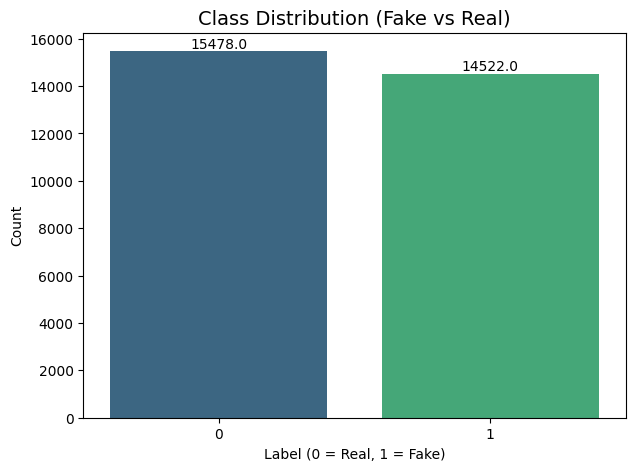

In [22]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=train_df, x='label', palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title("Class Distribution (Fake vs Real)", fontsize=14)
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

Measuring text lengths, generating distributions, comparing classes, and visualizing frequency patterns across categories.

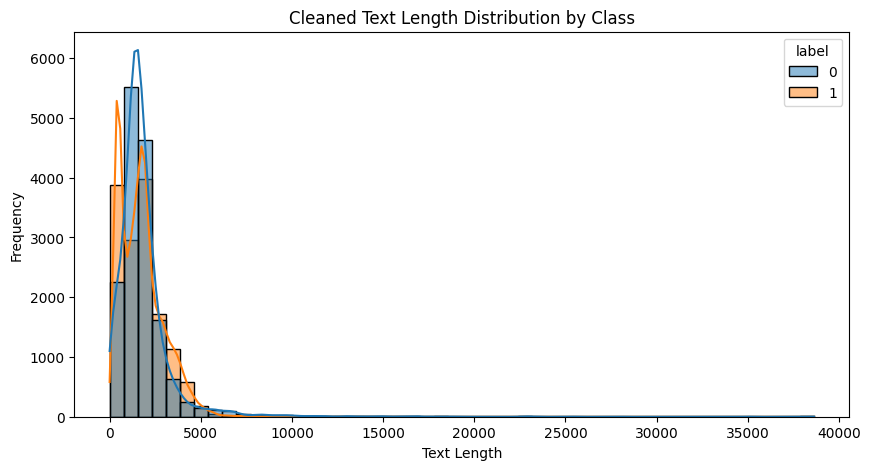

In [23]:
train_df['clean_length'] = train_df['clean_content'].apply(len)
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='clean_length', hue='label', bins=50, kde=True)
plt.title("Cleaned Text Length Distribution by Class")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

Computing word counts, analyzing distributions, comparing categories, and illustrating variations using boxplot visualization.

/tmp/ipykernel_1072/841342941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='word_count', palette='coolwarm')


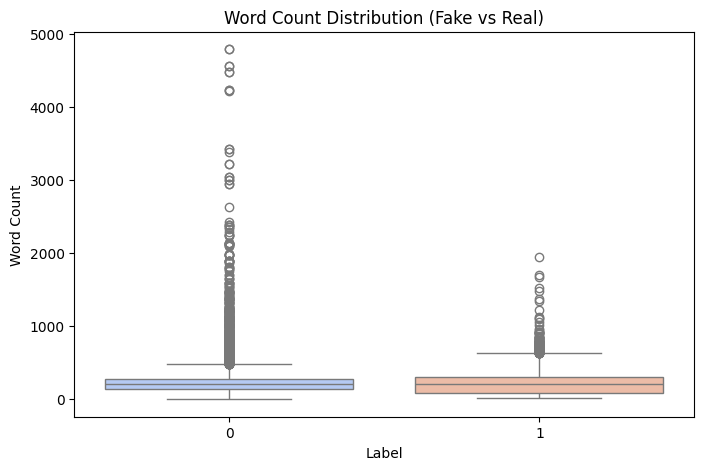

In [24]:
train_df['word_count'] = train_df['clean_content'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.boxplot(data=train_df, x='label', y='word_count', palette='coolwarm')
plt.title("Word Count Distribution (Fake vs Real)")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.show()

Extracting feature names, computing TF-IDF scores, selecting top terms, and visualizing important words.

/tmp/ipykernel_1072/2547166609.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='magma')


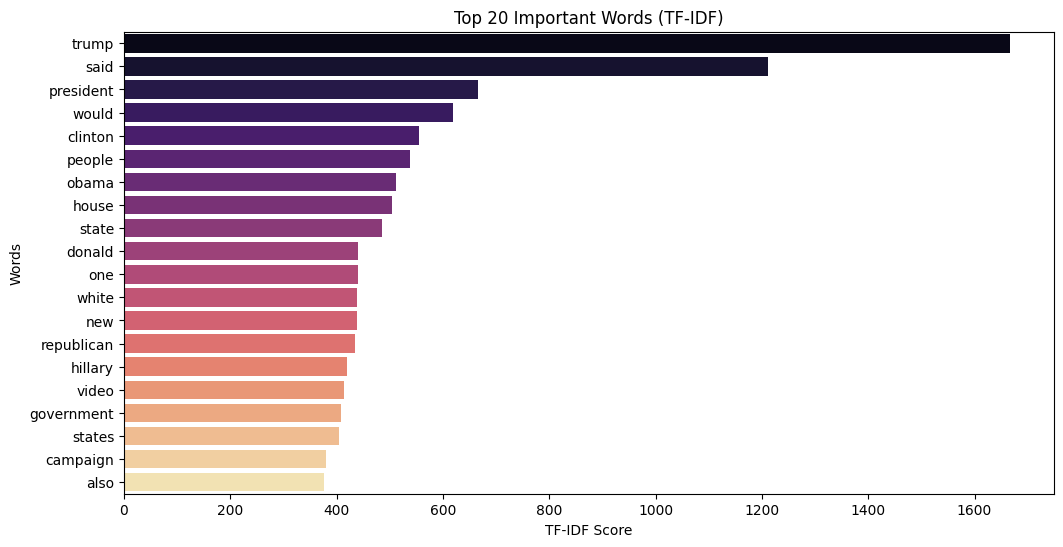

In [25]:
# Getting feature names
feature_names = tfidf.get_feature_names_out()
# Sum TF-IDF scores
tfidf_scores = np.asarray(X_train.sum(axis=0)).flatten()
# Top 20 words
top_n = 20
top_indices = tfidf_scores.argsort()[-top_n:][::-1]
top_words = [feature_names[i] for i in top_indices]
top_scores = tfidf_scores[top_indices]
plt.figure(figsize=(12,6))
sns.barplot(x=top_scores, y=top_words, palette='magma')
plt.title("Top 20 Important Words (TF-IDF)")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.show()

Separating class features, aggregating TF-IDF values, identifying top terms, and comparing word importance across categories.

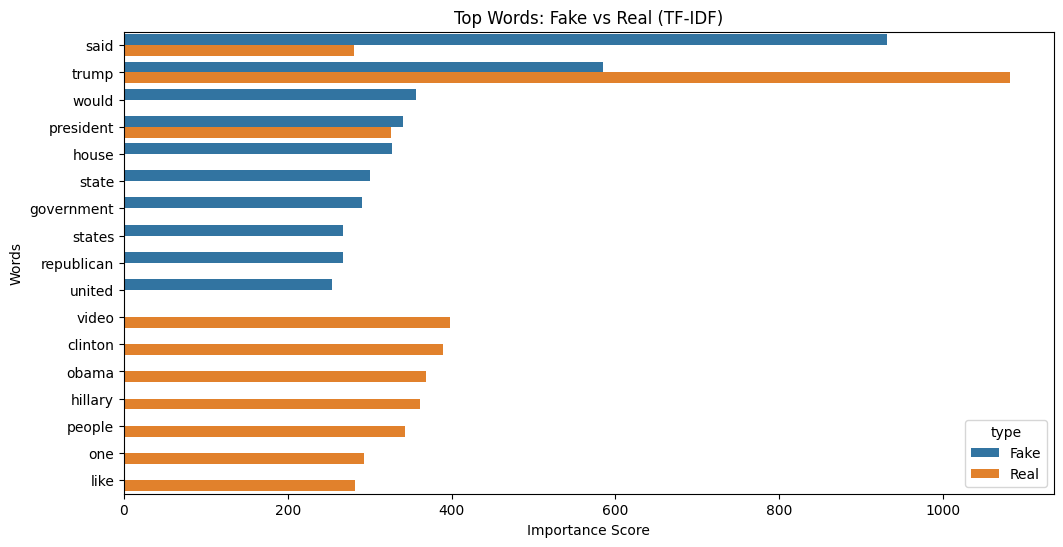

In [26]:
# Converting y_train to numpy array
y_train_np = y_train.values
# Boolean indexing (correct way)
fake_tfidf = X_train[y_train_np == 1].sum(axis=0)
real_tfidf = X_train[y_train_np == 0].sum(axis=0)
# Converting to 1D arrays
fake_scores = np.asarray(fake_tfidf).flatten()
real_scores = np.asarray(real_tfidf).flatten()
# Feature names
feature_names = tfidf.get_feature_names_out()
# Top words
top_fake_idx = fake_scores.argsort()[-10:][::-1]
top_real_idx = real_scores.argsort()[-10:][::-1]
fake_words = [feature_names[i] for i in top_fake_idx]
real_words = [feature_names[i] for i in top_real_idx]
fake_vals = fake_scores[top_fake_idx]
real_vals = real_scores[top_real_idx]

# Creating DataFrame
fake_df = pd.DataFrame({'word': fake_words, 'score': fake_vals, 'type': 'Fake'})
real_df = pd.DataFrame({'word': real_words, 'score': real_vals, 'type': 'Real'})
combined = pd.concat([fake_df, real_df])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=combined, x='score', y='word', hue='type')
plt.title("Top Words: Fake vs Real (TF-IDF)")
plt.xlabel("Importance Score")
plt.ylabel("Words")
plt.show()

Combining textual data, generating word cloud, highlighting frequent terms, and visualizing overall content patterns.

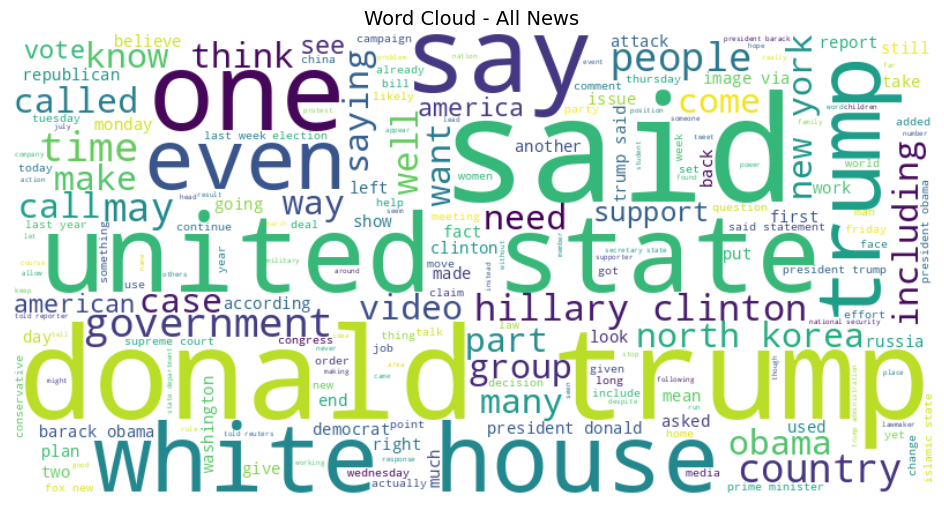

In [27]:
text_all = " ".join(train_df['clean_content'])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate(text_all)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - All News", fontsize=14)
plt.show()

Aggregating fake class text, generating word cloud, emphasizing frequent terms, and illustrating deceptive content patterns.

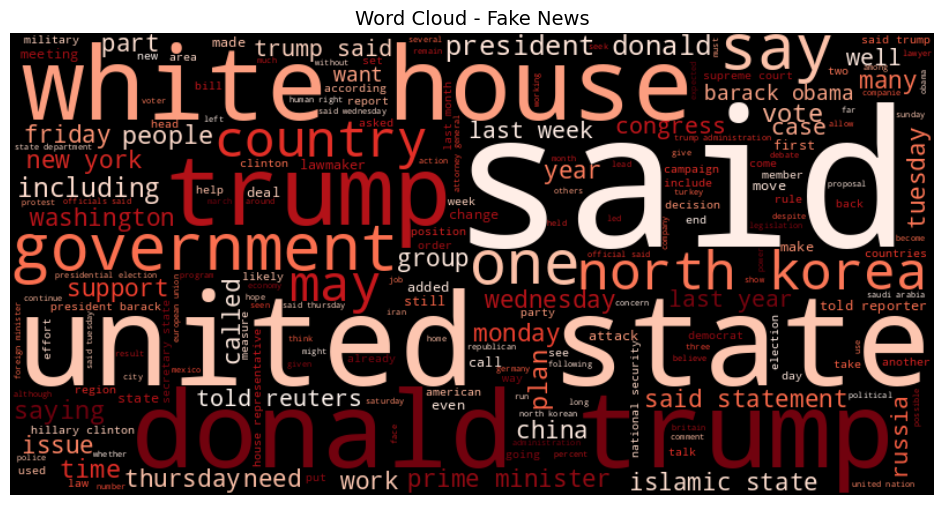

In [28]:
fake_text = " ".join(train_df[train_df['label']==1]['clean_content'])
wordcloud_fake = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Reds',
    max_words=200
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Fake News", fontsize=14)
plt.show()

Aggregating real class text, generating word cloud, highlighting dominant terms, and illustrating authentic content patterns.

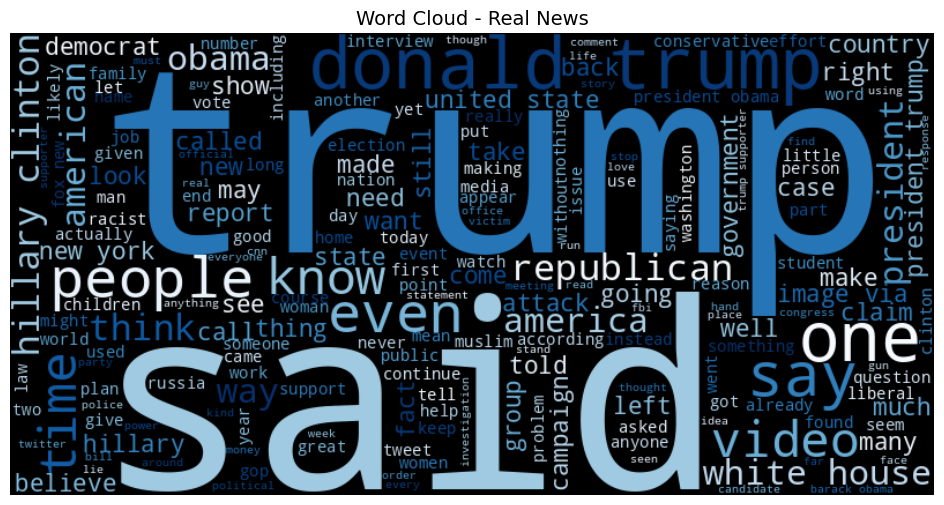

In [29]:
real_text = " ".join(train_df[train_df['label']==0]['clean_content'])
wordcloud_real = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Blues',
    max_words=200
).generate(real_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Real News", fontsize=14)
plt.show()

Arranging word clouds, displaying side-by-side views, contrasting categories, and highlighting differences in textual patterns.

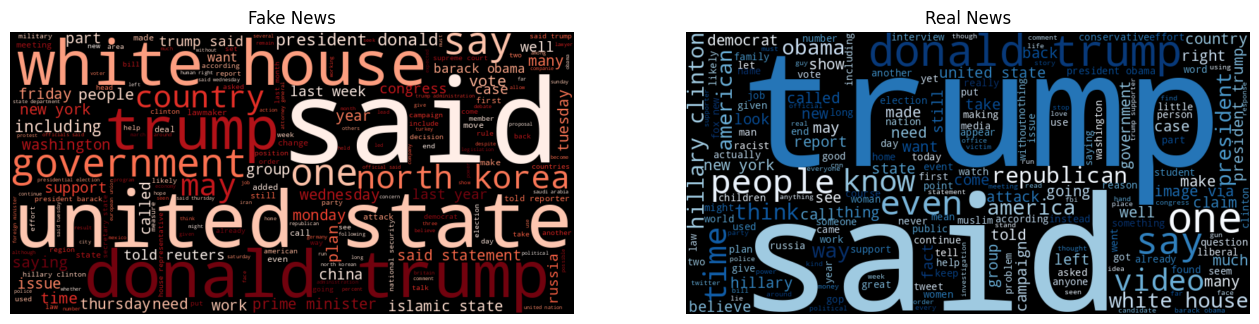

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].imshow(wordcloud_fake, interpolation='bilinear')
ax[0].set_title("Fake News")
ax[0].axis('off')
ax[1].imshow(wordcloud_real, interpolation='bilinear')
ax[1].set_title("Real News")
ax[1].axis('off')
plt.show()

Analyzing subject distribution, grouping categories, comparing class frequencies, and visualizing variations across topics.

In [31]:
# plt.figure(figsize=(12,6))
# # sns.countplot(data=train_df, y='subject', hue='label',
#               # order=train_df['subject'].value_counts().index)
# plt.title("Subject-wise Fake vs Real Distribution")
# plt.xlabel("Count")
# plt.ylabel("Subject")
# plt.legend(title="Label")
# plt.show()

Computing correlations, examining feature relationships, identifying dependencies, and visualizing interactions using heatmap representation.

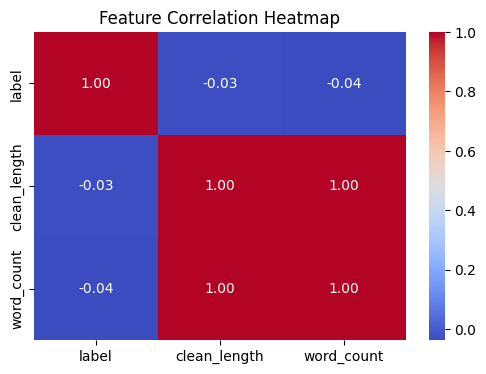

In [32]:
corr = train_df[['label', 'clean_length', 'word_count']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Training logistic regression model, fitting data, generating predictions, and evaluating performance using accuracy metrics.

In [33]:
# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(" Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test, y_pred_lr))

# Cross validation
cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=5)
print(" Logistic Regression CV Accuracy:", cv_scores_lr.mean())

 Logistic Regression Accuracy: 0.9820974960687069
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4284
           1       0.98      0.99      0.98      3983

    accuracy                           0.98      8267
   macro avg       0.98      0.98      0.98      8267
weighted avg       0.98      0.98      0.98      8267

 Logistic Regression CV Accuracy: 0.9803333333333333


Computing confusion matrix, comparing predicted labels, evaluating classification outcomes, and visualizing results using heatmap.

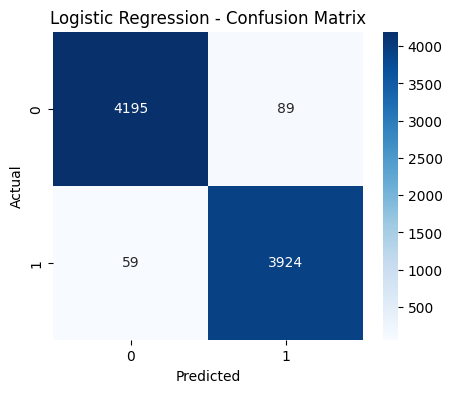

In [34]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Training support vector machine, fitting model, predicting outputs, and assessing performance using evaluation metrics.

In [35]:
# #SVM
# svm = LinearSVC()
# svm.fit(X_train, y_train)
# y_pred_svm = svm.predict(X_test)
# acc_svm = accuracy_score(y_test, y_pred_svm)
# print("SVM Accuracy:", acc_svm)
# print(classification_report(y_test, y_pred_svm))
# SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", acc_svm)
print(classification_report(y_test, y_pred_svm))

# Cross-validation
cv_scores_svm = cross_val_score(svm, X_train, y_train, cv=5)
print("SVM CV Accuracy:", cv_scores_svm.mean())

SVM Accuracy: 0.990564896576751
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      3983

    accuracy                           0.99      8267
   macro avg       0.99      0.99      0.99      8267
weighted avg       0.99      0.99      0.99      8267

SVM CV Accuracy: 0.9878333333333332


Generating confusion matrix, contrasting predicted outcomes, assessing classification errors, and visualizing results using heatmap.

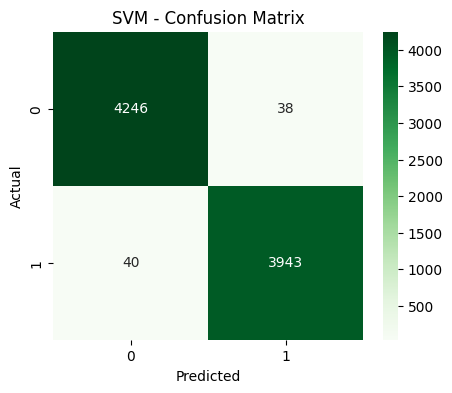

In [36]:
# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Training random forest model, constructing ensembles, predicting labels, and evaluating performance using classification metrics.

In [37]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

# cross validation
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5)
print("Random Forest CV Accuracy:", cv_scores_rf.mean())

Random Forest Accuracy: 0.9847586790855207
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.98      0.98      0.98      3983

    accuracy                           0.98      8267
   macro avg       0.98      0.98      0.98      8267
weighted avg       0.98      0.98      0.98      8267

Random Forest CV Accuracy: 0.9804333333333334


Building confusion matrix, comparing predicted classes, analyzing misclassifications, and presenting results through heatmap visualization.

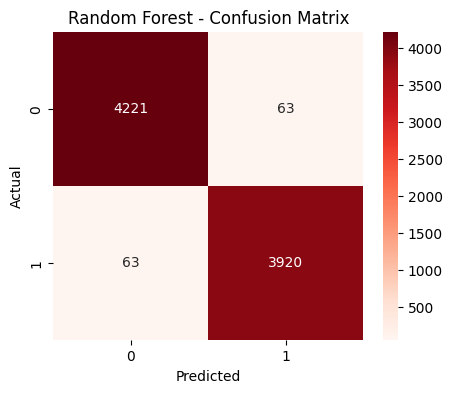

In [38]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Sampling dataset subsets, selecting instances, converting dataframes, and preparing inputs for transformer-based model training.

In [39]:
train_sample = train_df.sample(5000, random_state=42)
test_sample = test_df.sample(2000, random_state=42)
train_data = Dataset.from_pandas(train_sample[['content','label']])
test_data = Dataset.from_pandas(test_sample[['content','label']])

Sampling smaller datasets, tokenizing text, initializing transformer model, training network, and evaluating predictions efficiently.

In [40]:
# BERT MODEL
# USE LARGER SAMPLE
train_sample = train_df.sample(2000, random_state=42)
test_sample = test_df.sample(2000, random_state=42)

train_data = Dataset.from_pandas(train_sample[['content','label']])
test_data = Dataset.from_pandas(test_sample[['content','label']])

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['content'], truncation=True, padding='max_length', max_length=64)

train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

train_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])
test_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])

# Model
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Training Arguments
training_args = TrainingArguments(
    output_dir="./bert_fast",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    logging_steps=20,
    save_strategy="no",
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data
)

# Train
trainer.train()

# Predictions
predictions = trainer.predict(test_data)
y_pred_bert = np.argmax(predictions.predictions, axis=1)
y_true_bert = predictions.label_ids

# Metrics
acc_bert = accuracy_score(y_true_bert, y_pred_bert)

print(f"\nBERT Accuracy: {acc_bert:.4f}")
print(f"BERT F1 Score: {f1_score(y_true_bert, y_pred_bert):.4f}")
print(f"BERT Precision: {precision_score(y_true_bert, y_pred_bert):.4f}")
print(f"BERT Recall: {recall_score(y_true_bert, y_pred_bert):.4f}")
print("\nBERT Classification Report:\n")
print(classification_report(y_true_bert, y_pred_bert, digits=4))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,0.449188
40,0.340504
60,0.142961
80,0.381580
100,0.145295
120,0.149937
140,0.104456
160,0.053744
180,0.075905
200,0.049733



BERT Accuracy: 0.9730
BERT F1 Score: 0.9731
BERT Precision: 0.9663
BERT Recall: 0.9799

BERT Classification Report:

              precision    recall  f1-score   support

           0     0.9798    0.9662    0.9729      1005
           1     0.9663    0.9799    0.9731       995

    accuracy                         0.9730      2000
   macro avg     0.9731    0.9730    0.9730      2000
weighted avg     0.9731    0.9730    0.9730      2000



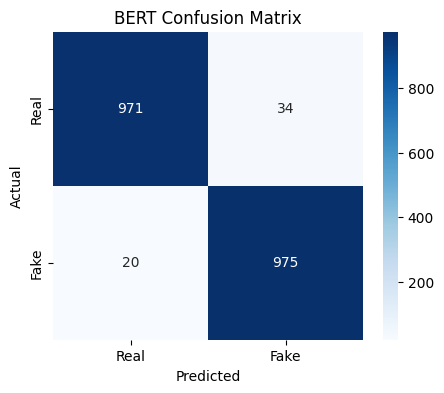

In [41]:
# Confusion Matrix
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Sampling subsets, tokenizing sequences, initializing RoBERTa model, training network, and evaluating predictions efficiently.

In [42]:
# # SAME SAMPLE
# train_sample = train_df.sample(1000, random_state=42)
# test_sample = test_df.sample(500, random_state=42)
# train_data = Dataset.from_pandas(train_sample[['content','label']])
# test_data = Dataset.from_pandas(test_sample[['content','label']])
# # Tokenizer (RoBERTa)
# tokenizer = AutoTokenizer.from_pretrained('roberta-base')
# def tokenize(example):
#     return tokenizer(
#         example['content'],
#         truncation=True,
#         padding='max_length',
#         max_length=64   )
# train_data = train_data.map(tokenize, batched=True)
# test_data = test_data.map(tokenize, batched=True)
# # Format for PyTorch
# train_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])
# test_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])
# # Model
# model = AutoModelForSequenceClassification.from_pretrained(
#     'roberta-base',
#     num_labels=2)
# # Training Arguments (CPU compatible)
# training_args = TrainingArguments(
#     output_dir="./roberta_fast",
#     per_device_train_batch_size=8,
#     num_train_epochs=1,
#     logging_steps=20,
#     save_strategy="no",
#     report_to="none")
# # Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_data)
# # Train
# trainer.train()
# # Manual Evaluation (IMPORTANT)
# predictions = trainer.predict(test_data)
# y_pred = np.argmax(predictions.predictions, axis=1)
# y_true = predictions.label_ids
# acc_roberta = (y_pred == y_true).mean()
# print("RoBERTa Accuracy (CPU FAST):", acc_roberta)

Sampling data, tokenizing inputs, training RoBERTa model, predicting outputs, evaluating accuracy, and visualizing confusion matrix.

In [43]:
#RoBERTa MODEL
train_sample = train_df.sample(2000, random_state=42)
test_sample = test_df.sample(2000, random_state=42)
train_data = Dataset.from_pandas(train_sample[['content','label']])
test_data = Dataset.from_pandas(test_sample[['content','label']])
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
def tokenize(example):
    return tokenizer(example['content'], truncation=True, padding='max_length', max_length=64)
train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)
train_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])
test_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])
# Model
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
# Training Arguments
training_args = TrainingArguments(
    output_dir="./roberta_fast",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    logging_steps=20,
    save_strategy="no",
    report_to="none"
)
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data
)
# Train
trainer.train()
# Predictions
predictions = trainer.predict(test_data)
y_pred_roberta = np.argmax(predictions.predictions, axis=1)
y_true_roberta = predictions.label_ids

# Metrics
acc_roberta = accuracy_score(y_true_roberta, y_pred_roberta)
print(f"\nRoBERTa Accuracy: {acc_roberta:.4f}")
print(f"RoBERTa F1 Score: {f1_score(y_true_roberta, y_pred_roberta):.4f}")
print(f"RoBERTa Precision: {precision_score(y_true_roberta, y_pred_roberta):.4f}")
print(f"RoBERTa Recall: {recall_score(y_true_roberta, y_pred_roberta):.4f}")
print("\nRoBERTa Classification Report:\n")
print(classification_report(y_true_roberta, y_pred_roberta, digits=4))

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,0.417530
40,0.301889
60,0.107313
80,0.041702
100,0.061140
120,0.000801
140,0.000577
160,0.000406
180,0.000347
200,0.000287



RoBERTa Accuracy: 0.9985
RoBERTa F1 Score: 0.9985
RoBERTa Precision: 0.9990
RoBERTa Recall: 0.9980

RoBERTa Classification Report:

              precision    recall  f1-score   support

           0     0.9980    0.9990    0.9985      1005
           1     0.9990    0.9980    0.9985       995

    accuracy                         0.9985      2000
   macro avg     0.9985    0.9985    0.9985      2000
weighted avg     0.9985    0.9985    0.9985      2000



Constructing confusion matrix, comparing predicted labels, evaluating classification performance, and visualizing outcomes using heatmap.

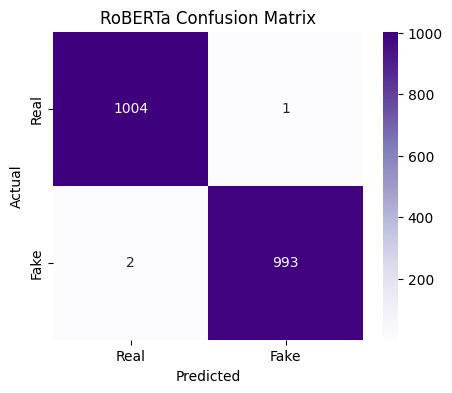

In [44]:
# Confusion Matrix
cm_roberta = confusion_matrix(y_true_roberta, y_pred_roberta)
# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_roberta, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.title("RoBERTa Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compiling model results, aggregating accuracy scores, organizing comparisons, and presenting performance across different models.

In [49]:
# Logistic Regression
f1_lr = f1_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)

# SVM
f1_svm = f1_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)

# Random Forest
f1_rf = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

# BERT
f1_bert = f1_score(y_true_bert, y_pred_bert)
prec_bert = precision_score(y_true_bert, y_pred_bert)
rec_bert = recall_score(y_true_bert, y_pred_bert)

# RoBERTa
f1_roberta = f1_score(y_true_roberta, y_pred_roberta)
prec_roberta = precision_score(y_true_roberta, y_pred_roberta)
rec_roberta = recall_score(y_true_roberta, y_pred_roberta)
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "BERT", "RoBERTa"],

    "Accuracy": [
        round(acc_lr, 4),
        round(acc_svm, 4),
        round(acc_rf, 4),
        round(acc_bert, 4),
        round(acc_roberta, 4)
    ],

    "F1-Score": [
        round(f1_lr, 4),
        round(f1_svm, 4),
        round(f1_rf, 4),
        round(f1_bert, 4),
        round(f1_roberta, 4)
    ],

    "Precision": [
        round(prec_lr, 4),
        round(prec_svm, 4),
        round(prec_rf, 4),
        round(prec_bert, 4),
        round(prec_roberta, 4)
    ],

    "Recall": [
        round(rec_lr, 4),
        round(rec_svm, 4),
        round(rec_rf, 4),
        round(rec_bert, 4),
        round(rec_roberta, 4)
    ]
})

print("\n FINAL MODEL COMPARISON TABLE:\n")
print(comparison_df)


 FINAL MODEL COMPARISON TABLE:

                 Model  Accuracy  F1-Score  Precision  Recall
0  Logistic Regression    0.9821    0.9815     0.9778  0.9852
1                  SVM    0.9906    0.9902     0.9905  0.9900
2        Random Forest    0.9848    0.9842     0.9842  0.9842
3                 BERT    0.9730    0.9731     0.9663  0.9799
4              RoBERTa    0.9985    0.9985     0.9990  0.9980


Visualizing model performance, comparing accuracy scores, plotting results, and highlighting differences across multiple models.

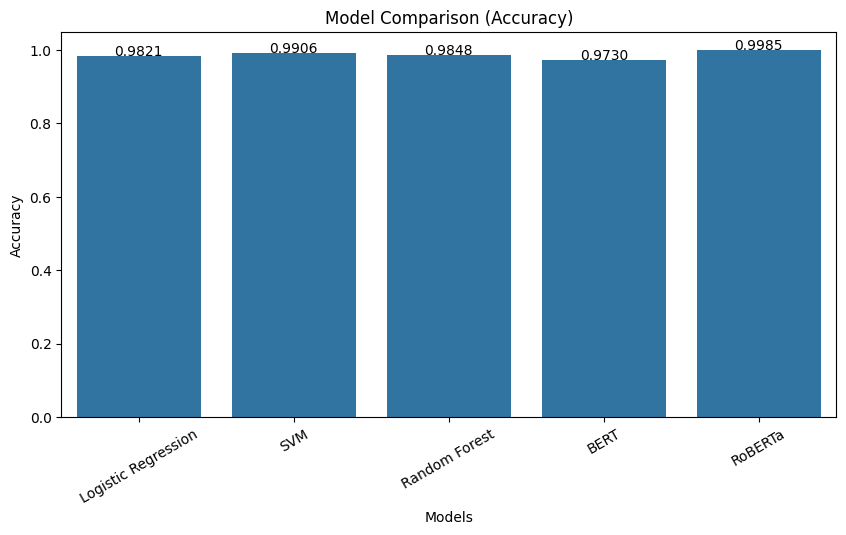

In [50]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "BERT",
        "RoBERTa"
    ],
    "Accuracy": [
        acc_lr,
        acc_svm,
        acc_rf,
        acc_bert,
        acc_roberta
    ]
})
plt.figure(figsize=(10,5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

# values show cheyyadaniki
for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')
plt.show()